# Practical 05 --- Settings in a File, Bugs Caught by a Robot

**YAML configuration and automated testing with pytest**

SCSE3040 Machine Learning Operations &middot; Bennett University &middot; Session 2026-27

| | |
|---|---|
| **Lectures this follows** | L08 |
| **Course Outcome** | CO3 |
| **Lab duration** | 120 minutes |
| **Memory needed** | about 450 MB (fine on a 4 GB or 8 GB machine) |
| **Extra software** | nothing beyond the course venv |
| **Marks** | 10 |

---

## Aim

1. Move every hardcoded setting out of your code and into a YAML file.
2. Read that file from Python and use it to control training.
3. Write automated tests that check your code without you watching.
4. Run the whole test suite with one command and read its report.

---

## What you need to know first


Two habits today. They look unrelated. They are both about the same thing:
being able to change your project safely.

**Configuration.** Your code is full of numbers somebody chose: the test size
of 0.2, the seed 42, the four column names. Right now they are typed into the
middle of your code. That is called a **magic number**, and it causes two
problems. To change one you must edit code, which risks breaking it. And to
find out what settings produced a result, someone must read every line.

The fix is to put settings in a separate file. We use **YAML** (YAML Ain't
Markup Language), a format designed to be read by humans. Indentation makes the
structure; no brackets, no commas. It is what Docker, Kubernetes and GitHub
Actions all use, so you will meet it constantly from P08 onwards.

**Testing.** Right now you check your code by looking at output and thinking
"that seems about right". That works until your project has forty functions,
and then it stops working entirely.

A **test** is a small piece of code that checks another piece of code, and says
PASS or FAIL without a human. **pytest** is the tool that finds all your tests
and runs them. One command, and you know whether anything broke.

The magic word is `assert`. `assert x == 5` does nothing at all if `x` is 5,
and raises an error if it is not. A test is just a function whose name starts
with `test_`, containing asserts.

Why this matters for MLOps: in P11 a server will run these tests automatically
every time you change your code, and refuse to deploy if any of them fail.

---

## Before you start

- Practical P04 is finished. You can write a module and import it.
- You know what a function is and what it means for one to return a value.

### How to run a cell

Click on a grey code cell, then press **Shift + Enter**. The cell runs and
the cursor moves to the next one. A number appears in the `[ ]` on the left
when the cell has finished.

**Run the cells in order, from the top.** A later cell almost always uses
something an earlier cell created. If you jump ahead you will see a
`NameError`, which just means "you have not made that thing yet".

If everything goes wrong, use the menu: **Kernel -> Restart Kernel and Clear
All Outputs**, then start again from the first cell. Nothing is damaged by
doing this.

In [1]:
# Step 0 --- check the workbench before we start.
# This cell only looks; it changes nothing. Run it and read the last line.

import sys
from pathlib import Path

print("Python  :", sys.version.split()[0])
print("Folder  :", Path.cwd().name)

_missing = []
for _name in ['numpy', 'pandas', 'sklearn', 'yaml', 'pytest', 'matplotlib']:
    try:
        __import__(_name)
    except ImportError:
        _missing.append(_name)

for _name in ['numpy', 'pandas', 'sklearn', 'yaml', 'pytest', 'matplotlib']:
    _mark = "missing" if _name in _missing else "ok"
    print(f"  {_name:<14} {_mark}")

if _missing:
    print()
    print("STOP. Some libraries are missing:", ", ".join(_missing))
    print("Ask your instructor to run the setup in labs/SETUP.md.")
else:
    print()
    print("All good. You can carry on to Step 1.")

Python  : 3.13.9
Folder  : P05-config-tests
  numpy          ok
  pandas         ok
  sklearn        ok
  yaml           ok
  pytest         ok
  matplotlib     ok

All good. You can carry on to Step 1.


---

## Step 0b --- the dataset

Every practical in this course uses the same 600 food deliveries.
The next cell makes sure the file is there.

In [2]:
# The delivery-time dataset every practical in this course uses.
# If the file is missing we build it again from the same seed, so every
# student in the room gets byte-for-byte the same 600 rows.

import csv
from pathlib import Path

import numpy as np

SEED = 42
N_ROWS = 600
DATA = Path("..") / "data" / "delivery_times.csv"


def make_delivery_csv(path=DATA):
    """Write the 600-row delivery dataset. Same formula as the lectures."""
    rng = np.random.default_rng(SEED)
    distance_km = np.round(rng.uniform(0.5, 12.0, N_ROWS), 2)
    prep_time_min = np.round(rng.uniform(5, 30, N_ROWS), 0)
    traffic_level = rng.integers(1, 4, N_ROWS)
    rain = rng.binomial(1, 0.25, N_ROWS)
    delivery_min = np.round(
        6.0
        + 3.1 * distance_km
        + 0.65 * prep_time_min
        + 4.2 * traffic_level
        + 5.5 * rain
        + rng.normal(0, 2.5, N_ROWS),
        1,
    )
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as fh:
        w = csv.writer(fh)
        w.writerow(["distance_km", "prep_time_min", "traffic_level",
                    "rain", "delivery_min"])
        for i in range(N_ROWS):
            w.writerow([distance_km[i], int(prep_time_min[i]),
                        int(traffic_level[i]), int(rain[i]), delivery_min[i]])
    return path


if not DATA.exists():
    make_delivery_csv()
    print("dataset rebuilt ->", DATA)
else:
    print("dataset found   ->", DATA)

dataset found   -> ..\data\delivery_times.csv


---

# Walkthrough

Read each step, then run its cell.

### Step 1 --- Look at the problem: settings buried in code

Here is training code in the style you have written so far. Count
the numbers and names that somebody chose. There are seven.

In [3]:
from pathlib import Path

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

WORK = Path("work")
WORK.mkdir(exist_ok=True)

orders = pd.read_csv(DATA)
X = orders[["distance_km", "prep_time_min", "traffic_level", "rain"]]
y = orders["delivery_min"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                          random_state=42)
mae = mean_absolute_error(y_te, LinearRegression().fit(X_tr, y_tr)
                          .predict(X_te))
print(f"MAE {mae:.2f}")

MAE 1.92


To try a 70/30 split you must edit that line. To find out what split
produced yesterday's number, you must read the code as it was
yesterday. Both are avoidable.

### Step 2 --- Write the settings into a YAML file

YAML rules you need today, and no more:

- `key: value` gives one setting
- indentation with **spaces** groups settings together
- `- item` makes a list
- `#` starts a comment

Never use tab characters in YAML. It is the single most common
mistake, and the error message will not tell you.

In [4]:
config_yaml = """# Settings for the delivery-time model.
# Change values here, never in the code.

data:
  path: ../data/delivery_times.csv
  features:
    - distance_km
    - prep_time_min
    - traffic_level
    - rain
  target: delivery_min

split:
  test_size: 0.2
  seed: 42

model:
  name: linear_regression
"""

(WORK / "config.yaml").write_text(config_yaml, encoding="utf-8")
print((WORK / "config.yaml").read_text(encoding="utf-8"))

# Settings for the delivery-time model.
# Change values here, never in the code.

data:
  path: ../data/delivery_times.csv
  features:
    - distance_km
    - prep_time_min
    - traffic_level
    - rain
  target: delivery_min

split:
  test_size: 0.2
  seed: 42

model:
  name: linear_regression



### Step 3 --- Read the file into Python

`yaml.safe_load` turns that text into ordinary Python dictionaries
and lists. Always `safe_load`, never `load` --- the unsafe version
can execute code hidden inside a file somebody sent you.

In [5]:
import yaml

with open(WORK / "config.yaml", encoding="utf-8") as fh:
    config = yaml.safe_load(fh)

print(type(config))
print()
print("features :", config["data"]["features"])
print("test size:", config["split"]["test_size"])
print("seed     :", config["split"]["seed"])

<class 'dict'>

features : ['distance_km', 'prep_time_min', 'traffic_level', 'rain']
test size: 0.2
seed     : 42


It is a dictionary of dictionaries. `config["split"]["seed"]` reads
exactly like the file looks, which is the whole point of YAML.

### Step 4 --- Train using only the config

Same training as Step 1, but now there is not one chosen number in
the code. Every setting comes from the file.

In [6]:
def train_from_config(config, data_path):
    """Train and score, taking every setting from the config."""
    orders = pd.read_csv(data_path)
    X = orders[config["data"]["features"]]
    y = orders[config["data"]["target"]]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y,
        test_size=config["split"]["test_size"],
        random_state=config["split"]["seed"],
    )
    model = LinearRegression().fit(X_tr, y_tr)
    return model, mean_absolute_error(y_te, model.predict(X_te))


model, mae = train_from_config(config, DATA)
print(f"MAE {mae:.2f} minutes")

MAE 1.92 minutes


Now change `test_size` to `0.3` in your head. You would edit one
line of a settings file --- no code review, no risk of a typo
breaking training.

### Step 5 --- Prove it: change a setting, get a different run

Watch the config actually control the behaviour.

In [7]:
for test_size in [0.2, 0.3, 0.4]:
    config["split"]["test_size"] = test_size
    _, mae = train_from_config(config, DATA)
    print(f"test_size {test_size} -> MAE {mae:.2f}")

config["split"]["test_size"] = 0.2   # put it back

test_size 0.2 -> MAE 1.92
test_size 0.3 -> MAE 2.01
test_size 0.4 -> MAE 2.04


### Step 6 --- Draw what the settings change

Three printed numbers are easy to forget. Draw them, and add the
other setting somebody chose: the seed.

Left: the same code and data, five different `test_size` values.
Right: the same code and data, five different seeds. Every bar is
an honest score. None of them is *the* MAE.

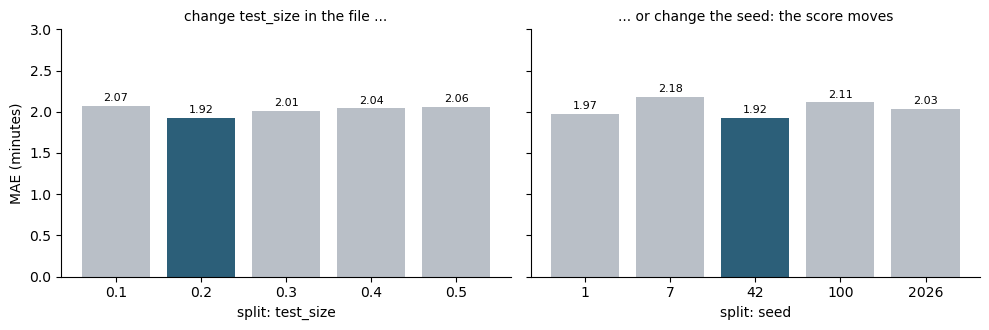

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

sizes = [0.1, 0.2, 0.3, 0.4, 0.5]
mae_by_size = []
for test_size in sizes:
    config["split"]["test_size"] = test_size
    mae_by_size.append(train_from_config(config, DATA)[1])
config["split"]["test_size"] = 0.2          # put it back

seeds = [1, 7, 42, 100, 2026]
mae_by_seed = []
for seed in seeds:
    config["split"]["seed"] = seed
    mae_by_seed.append(train_from_config(config, DATA)[1])
config["split"]["seed"] = 42                # put it back

fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.4),
                                  sharey=True)
bars = left.bar([str(s) for s in sizes], mae_by_size,
                color=["#2C5F79" if s == 0.2 else "#B9BFC7"
                       for s in sizes])
left.bar_label(bars, fmt="%.2f", padding=2, fontsize=8)
left.set_xlabel("split: test_size")
left.set_ylabel("MAE (minutes)")
left.set_title("change test_size in the file ...", fontsize=10)

bars = right.bar([str(s) for s in seeds], mae_by_seed,
                 color=["#2C5F79" if s == 42 else "#B9BFC7"
                        for s in seeds])
right.bar_label(bars, fmt="%.2f", padding=2, fontsize=8)
right.set_xlabel("split: seed")
right.set_title("... or change the seed: the score moves",
                fontsize=10)

for ax in (left, right):
    ax.set_ylim(0, 3)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

The blue bars are the settings in `config.yaml` today. Nothing is
broken when a grey bar is higher or lower --- the model is the
same, only the split changed. That is exactly why chosen numbers
live in a file: "MAE 2.03" means nothing unless you can also say
which `test_size` and which seed produced it.

### Step 7 --- Now testing. What is an assert?

An `assert` says "this must be true". If it is, nothing happens. If
it is not, Python stops and complains.

Run this cell. The first two lines do nothing visible. The third one
is caught and printed on purpose.

In [9]:
assert 2 + 2 == 4
assert "delivery".startswith("del")

try:
    assert 2 + 2 == 5, "arithmetic is broken"
except AssertionError as problem:
    print("AssertionError:", problem)

AssertionError: arithmetic is broken


That is the whole idea. A test is a function full of asserts.

### Step 8 --- Write a module worth testing

Tests need something to test. Here is a small module with two
functions and one deliberate rule: a delivery cannot cover zero
distance.

In [10]:
orders_py = '''"Small helpers for delivery orders."

TRAFFIC_LEVELS = (1, 2, 3)


def minutes_per_km(delivery_min, distance_km):
    "How many minutes each kilometre took."
    if distance_km <= 0:
        raise ValueError("distance_km must be positive")
    return delivery_min / distance_km


def is_valid_order(order):
    "True if this order is usable for training."
    if order.get("distance_km", 0) <= 0:
        return False
    if order.get("prep_time_min", 0) < 0:
        return False
    if order.get("traffic_level") not in TRAFFIC_LEVELS:
        return False
    if order.get("rain") not in (0, 1):
        return False
    return True
'''

(WORK / "orders.py").write_text(orders_py, encoding="utf-8")
print("wrote", WORK / "orders.py")

wrote work\orders.py


### Step 9 --- Write the tests

Three rules pytest follows, and they are all naming rules:

- the file must be called `test_something.py`
- each test must be a function called `test_something`
- inside, use plain `assert`

Notice the third test: it checks that a **bad** input raises an
error. Testing that things fail properly is as important as testing
that they work.

In [11]:
test_py = '''"Tests for orders.py."

import pytest

from orders import is_valid_order, minutes_per_km


def test_minutes_per_km_simple():
    assert minutes_per_km(30, 10) == 3.0


def test_minutes_per_km_rejects_zero_distance():
    with pytest.raises(ValueError):
        minutes_per_km(30, 0)


def test_good_order_is_accepted():
    good = {"distance_km": 5.0, "prep_time_min": 20,
            "traffic_level": 2, "rain": 0}
    assert is_valid_order(good) is True


def test_bad_traffic_level_is_rejected():
    bad = {"distance_km": 5.0, "prep_time_min": 20,
           "traffic_level": 9, "rain": 0}
    assert is_valid_order(bad) is False
'''

(WORK / "test_orders.py").write_text(test_py, encoding="utf-8")
print("wrote", WORK / "test_orders.py")

wrote work\test_orders.py


### Step 10 --- Run the tests with one command

`pytest` finds every `test_*.py` file, runs every `test_*` function,
and reports. A dot means a pass, an `F` means a failure.

In [12]:
import subprocess
import sys

def run_pytest(*extra):
    """Run pytest inside work/ and print its report."""
    done = subprocess.run(
        [sys.executable, "-m", "pytest", "-v", *extra],
        cwd=WORK, capture_output=True, text=True,
    )
    print(done.stdout[-2500:])
    print("exit code:", done.returncode,
          "(0 means every test passed)")
    return done


run = run_pytest()

============================= test session starts =============================
platform win32 -- Python 3.13.9, pytest-8.3.4, pluggy-1.5.0 -- c:\Users\Dell\anaconda3\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\Dell\SCSE3040-Lab\P05-config-tests\work
plugins: anyio-4.7.0
collecting ... collected 10 items

test_model.py::test_rain_never_makes_delivery_faster PASSED              [ 10%]
test_model.py::test_further_is_never_faster PASSED                       [ 20%]
test_model.py::test_error_is_better_than_guessing PASSED                 [ 30%]
test_model.py::test_heavier_traffic_is_never_faster PASSED               [ 40%]
test_orders.py::test_minutes_per_km_simple PASSED                        [ 50%]
test_orders.py::test_minutes_per_km_rejects_zero_distance PASSED         [ 60%]
test_orders.py::test_good_order_is_accepted PASSED                       [ 70%]
test_orders.py::test_bad_traffic_level_is_rejected PASSED                [ 80%]
test_speed.py::test_slow_delivery PASSED    

Four tests, four passes, exit code 0. That exit code is what a
pipeline reads in P11 to decide whether your change is allowed to
go live.

### Step 11 --- Break something on purpose

A test suite you have never seen fail is a test suite you should not
trust. Let us break the module and watch pytest catch it.

In [13]:
broken = (WORK / "orders.py").read_text(encoding="utf-8")
(WORK / "orders.py").write_text(
    broken.replace("return delivery_min / distance_km",
                   "return delivery_min * distance_km"),
    encoding="utf-8",
)

broken_run = run_pytest()

(WORK / "orders.py").write_text(broken, encoding="utf-8")  # repair
print()
print("module repaired")

rootdir: c:\Users\Dell\SCSE3040-Lab\P05-config-tests\work
plugins: anyio-4.7.0
collecting ... collected 10 items

test_model.py::test_rain_never_makes_delivery_faster PASSED              [ 10%]
test_model.py::test_further_is_never_faster PASSED                       [ 20%]
test_model.py::test_error_is_better_than_guessing PASSED                 [ 30%]
test_model.py::test_heavier_traffic_is_never_faster PASSED               [ 40%]
test_orders.py::test_minutes_per_km_simple FAILED                        [ 50%]
test_orders.py::test_minutes_per_km_rejects_zero_distance PASSED         [ 60%]
test_orders.py::test_good_order_is_accepted PASSED                       [ 70%]
test_orders.py::test_bad_traffic_level_is_rejected PASSED                [ 80%]
test_speed.py::test_slow_delivery FAILED                                 [ 90%]
test_speed.py::test_negative_distance_raises PASSED                      [100%]

================================== FAILURES ===================================
_____

Read the failure report. pytest shows you the line, the values it
compared, and what it expected. That report is why you write tests
instead of print statements.

### Step 12 --- Draw the two runs, the way a pipeline shows them

In P11 a server will run this suite for you and show one row per
test, coloured by result. You do not need the server to see that
picture: `-v` already prints one line per test, so read those
lines back and draw them.

Left: the green run from two steps ago. Right: the broken run.
The word on each bar says the same thing as its colour.

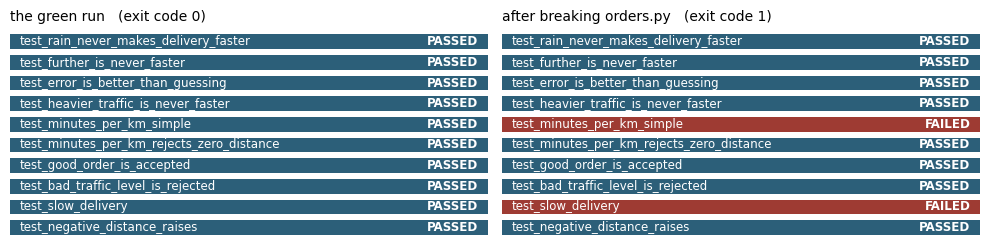

In [14]:
%matplotlib inline
import re

import matplotlib.pyplot as plt

def test_results(run):
    """Read pytest's -v report into (test name, PASSED/FAILED)."""
    plain = re.sub(r"\x1b\[[0-9;]*m", "", run.stdout)  # drop colours
    found = re.findall(r"^(\S+::\S+) (PASSED|FAILED|ERROR)",
                       plain, flags=re.M)
    return [(name.split("::")[-1], status) for name, status in found]


def draw_test_board(run, ax, title):
    """One bar per test, blue for a pass, red for a failure."""
    results = test_results(run)[::-1]          # first test on top
    colours = ["#2C5F79" if s == "PASSED" else "#9E3B33"
               for _, s in results]
    ax.barh(range(len(results)), [1] * len(results),
            color=colours, height=0.7)
    for i, (name, status) in enumerate(results):
        ax.text(0.02, i, name, ha="left", va="center",
                color="white", fontsize=8.5)
        ax.text(0.98, i, status, ha="right", va="center",
                color="white", fontsize=8.5, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylim(-0.6, len(results) - 0.4)
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(False)
    ax.set_title(f"{title}   (exit code {run.returncode})",
                 fontsize=10, loc="left")


fig, (left, right) = plt.subplots(1, 2, figsize=(10, 2.6))
draw_test_board(run, left, "the green run")
draw_test_board(broken_run, right, "after breaking orders.py")
plt.tight_layout()
plt.show()

One red bar, and the exit code went from 0 to 1. A pipeline reads
only that exit code, and a person reads only the red bar; neither
has to open a log to know something broke. Keep `draw_test_board`
--- you can draw your own runs from Tasks T2 and T3 with it.

### Step 13 --- Test the model's behaviour, not its exact score

Testing machine learning has one trap: never assert `mae == 2.03`.
That test breaks the day someone adds data, and it tells you
nothing.

Test **behaviour** that must always hold instead. Rain must never
make a delivery faster. That is true of any correct model.

In [15]:
model_test_py = '''"Behaviour tests for the trained model."

import pandas as pd


def make_order(distance_km=5.0, prep_time_min=20,
               traffic_level=2, rain=0):
    return pd.DataFrame([{
        "distance_km": distance_km,
        "prep_time_min": prep_time_min,
        "traffic_level": traffic_level,
        "rain": rain,
    }])


def test_rain_never_makes_delivery_faster(trained_model):
    dry = trained_model.predict(make_order(rain=0))[0]
    wet = trained_model.predict(make_order(rain=1))[0]
    assert wet >= dry


def test_further_is_never_faster(trained_model):
    near = trained_model.predict(make_order(distance_km=2))[0]
    far = trained_model.predict(make_order(distance_km=12))[0]
    assert far > near


def test_error_is_better_than_guessing(model_mae, baseline_mae):
    assert model_mae < baseline_mae
'''

(WORK / "test_model.py").write_text(model_test_py, encoding="utf-8")
print("wrote", WORK / "test_model.py")

wrote work\test_model.py


Those tests need a trained model. Rather than train inside every
test, pytest lets you prepare shared things once, in a file called
`conftest.py`. Each prepared thing is called a **fixture**, and a
test asks for one just by naming it as an argument.

### Step 14 --- Share setup with conftest.py

`conftest.py` is a special name pytest looks for automatically. You
never import it. Anything decorated with `@pytest.fixture` in it can
be requested by name from any test.

In [16]:
conftest_py = '''"Shared setup for every test in this folder."

from pathlib import Path

import pandas as pd
import pytest
import yaml
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

HERE = Path(__file__).resolve().parent


@pytest.fixture(scope="session")
def config():
    with open(HERE / "config.yaml", encoding="utf-8") as fh:
        return yaml.safe_load(fh)


@pytest.fixture(scope="session")
def split(config):
    data_path = HERE.parent.parent / "data" / "delivery_times.csv"
    orders = pd.read_csv(data_path)
    X = orders[config["data"]["features"]]
    y = orders[config["data"]["target"]]
    return train_test_split(
        X, y,
        test_size=config["split"]["test_size"],
        random_state=config["split"]["seed"],
    )


@pytest.fixture(scope="session")
def trained_model(split):
    X_tr, _, y_tr, _ = split
    return LinearRegression().fit(X_tr, y_tr)


@pytest.fixture(scope="session")
def model_mae(trained_model, split):
    _, X_te, _, y_te = split
    return mean_absolute_error(y_te, trained_model.predict(X_te))


@pytest.fixture(scope="session")
def baseline_mae(split):
    _, X_te, y_tr, y_te = split
    guess = [y_tr.mean()] * len(y_te)
    return mean_absolute_error(y_te, guess)
'''

(WORK / "conftest.py").write_text(conftest_py, encoding="utf-8")
run_pytest("-q")

============================= test session starts =============================
platform win32 -- Python 3.13.9, pytest-8.3.4, pluggy-1.5.0
rootdir: c:\Users\Dell\SCSE3040-Lab\P05-config-tests\work
plugins: anyio-4.7.0
collected 9 items

test_model.py ...                                                        [ 33%]
test_orders.py ....                                                      [ 77%]
test_speed.py ..                                                         [100%]

============================== 9 passed in 0.17s ==============================

exit code: 0 (0 means every test passed)


CompletedProcess(args=['c:\\Users\\Dell\\anaconda3\\python.exe', '-m', 'pytest', '-v', '-q'], returncode=0, stdout='\x1b============================= test session starts =============================\x1b\nplatform win32 -- Python 3.13.9, pytest-8.3.4, pluggy-1.5.0\nrootdir: c:\\Users\\Dell\\SCSE3040-Lab\\P05-config-tests\\work\nplugins: anyio-4.7.0\ncollected 9 items\n\ntest_model.py \x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b                                                        [ 33%]\x1b\ntest_orders.py \x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b                                                      [ 77%]\x1b\ntest_speed.py \x1b.\x1b\x1b.\x1b\x1b                                                         [100%]\x1b\n\n\x1b============================== \x1b\x1b9 passed\x1b\x1b in 0.17s\x1b\x1b ==============================\x1b\n', stderr='')

Seven tests now: four about the helper functions, three about the
model's behaviour. All from one command.

### Step 15 --- Draw what the behaviour tests promise

Each of the three model tests checks one shape that must hold for
**any** correct delivery model, on any data. Draw the three shapes
from the model you trained in Step 4.

Left: the same order, dry and in rain. Middle: the same order at
every distance from 1 km to 12 km. Right: the model's error
against the "always guess the average" baseline.

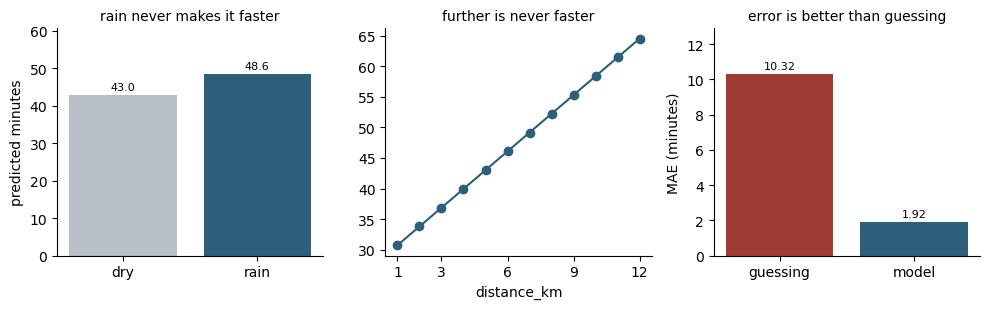

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt


def order(**changes):
    """One typical order, with some fields changed."""
    base = {"distance_km": 5.0, "prep_time_min": 20,
            "traffic_level": 2, "rain": 0}
    return pd.DataFrame([{**base, **changes}])


# the same split conftest.py builds, so the two errors are comparable
orders = pd.read_csv(DATA)
X_tr, X_te, y_tr, y_te = train_test_split(
    orders[config["data"]["features"]],
    orders[config["data"]["target"]],
    test_size=config["split"]["test_size"],
    random_state=config["split"]["seed"],
)
model_mae = mean_absolute_error(y_te, model.predict(X_te))
baseline_mae = mean_absolute_error(y_te, [y_tr.mean()] * len(y_te))

fig, (a, b, c) = plt.subplots(1, 3, figsize=(10, 3.2))

dry, wet = (float(model.predict(order(rain=r))[0]) for r in (0, 1))
bars = a.bar(["dry", "rain"], [dry, wet], color=["#B9BFC7", "#2C5F79"])
a.bar_label(bars, fmt="%.1f", padding=2, fontsize=8)
a.set_ylim(0, max(dry, wet) * 1.25)
a.set_ylabel("predicted minutes")
a.set_title("rain never makes it faster", fontsize=10)

kms = list(range(1, 13))
b.plot(kms, [float(model.predict(order(distance_km=k))[0]) for k in kms],
       marker="o", color="#2C5F79")
b.set_xticks([1, 3, 6, 9, 12])
b.set_xlabel("distance_km")
b.set_title("further is never faster", fontsize=10)

bars = c.bar(["guessing", "model"], [baseline_mae, model_mae],
             color=["#9E3B33", "#2C5F79"])
c.bar_label(bars, fmt="%.2f", padding=2, fontsize=8)
c.set_ylim(0, baseline_mae * 1.25)
c.set_ylabel("MAE (minutes)")
c.set_title("error is better than guessing", fontsize=10)

for ax in (a, b, c):
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Rain is the taller bar, the distance line only goes up, and the
model bar is far below the guessing bar. Add a hundred new
deliveries and every one of those shapes survives, while the exact
score in Step 6 moved with every seed. Test shapes, not numbers.
Task T3 adds a fourth shape: heavier traffic is never faster.

---

# Your turn

The walkthrough above is finished. Now you write some code.

There are **3 tasks**. Each one is small. Each one has a hint.
Do them in order.

Where you see `# TODO`, replace that line with your own code. Do not delete
the variable name on the left of the `=` sign --- the self-check at the
bottom looks for exactly that name.

When you have tried all three, run the **self-check** cell at the end. It
prints a table telling you which tasks are correct. You can run it as many
times as you like.

### Task T1 --- Add a setting, and use it


    Add a new section to the config called `training`, with one setting
    inside it: `max_rows`, set to `300`.

    Then write a function `train_limited(config, data_path)` that trains on
    only the first `max_rows` orders of the dataset and returns the MAE.

    Store the result of calling it in `T1_mae`.


> **Hint.** You already have `config` as a dictionary, so you can add to it directly: `config["training"] = {"max_rows": 300}`. In the function, read the CSV then cut it down with `orders.head(config["training"]["max_rows"])` before splitting.

In [22]:
# TODO: add a "training" section with max_rows set to 300
config["training"] = {"max_rows": 300}


def train_limited(config, data_path):
    """Train and score using only the first max_rows orders."""
    orders = pd.read_csv(data_path)

    # Keep only the first max_rows orders
    orders = orders.head(config["training"]["max_rows"])

    # Use the same features and target as train_from_config
    X = orders[config["data"]["features"]]
    y = orders[config["data"]["target"]]

    # Use the same train/test split as train_from_config
    X_tr, X_te, y_tr, y_te = train_test_split(
        X,
        y,
        test_size=config["split"]["test_size"],
        random_state=config["split"]["seed"],
    )

    # Train the same model
    model = LinearRegression().fit(X_tr, y_tr)

    # Return the MAE
    return mean_absolute_error(y_te, model.predict(X_te))


T1_mae = train_limited(config, DATA)
print("MAE on the first 300 orders:", T1_mae)

MAE on the first 300 orders: 2.1781751077589733


### Task T2 --- Write a test of your own


    Add a **new test file** `work/test_speed.py` containing two tests for
    `minutes_per_km` from `orders.py`:

    1. `test_slow_delivery` --- 60 minutes over 6 km must give 10.0
    2. `test_negative_distance_raises` --- a distance of `-3` must raise
       `ValueError`

    Then run the whole suite and store the finished process in `T2_run`.


> **Hint.** Copy the shape of `test_orders.py` from Step 9. For the second test you need `with pytest.raises(ValueError):` around the call. Run everything with `T2_run = run_pytest("-q")`.

In [23]:
speed_test_py = '''"My own tests for minutes_per_km."

import pytest

from orders import minutes_per_km


def test_slow_delivery():
    # 60 minutes over 6 km should be 10.0 minutes/km
    assert minutes_per_km(60, 6) == 10.0


def test_negative_distance_raises():
    # Negative distance should raise ValueError
    with pytest.raises(ValueError):
        minutes_per_km(60, -3)
'''

(WORK / "test_speed.py").write_text(speed_test_py, encoding="utf-8")

# Run the whole test suite
T2_run = run_pytest("-q")

print(T2_run.stdout)

============================= test session starts =============================
platform win32 -- Python 3.13.9, pytest-8.3.4, pluggy-1.5.0
rootdir: c:\Users\Dell\SCSE3040-Lab\P05-config-tests\work
plugins: anyio-4.7.0
collected 10 items

test_model.py ....                                                       [ 40%]
test_orders.py ....                                                      [ 80%]
test_speed.py ..                                                         [100%]

============================= 10 passed in 0.25s ==============================

exit code: 0 (0 means every test passed)
============================= test session starts =============================
platform win32 -- Python 3.13.9, pytest-8.3.4, pluggy-1.5.0
rootdir: c:\Users\Dell\SCSE3040-Lab\P05-config-tests\work
plugins: anyio-4.7.0
collected 10 items

test_model.py ....                                                       [ 40%]
test_orders.py ....                                                      [ 80%]

### Task T3 --- A behaviour test for the model


    Add one more test to `work/test_model.py` --- **append**, do not
    replace the file --- called `test_heavier_traffic_is_never_faster`.

    Using the `trained_model` fixture, it must assert that an order in
    traffic level 3 is predicted to take at least as long as the same order
    in traffic level 1.

    Run the suite again and store the process in `T3_run`.


> **Hint.** The file already has a `make_order(...)` helper --- use `make_order(traffic_level=1)` and `make_order(traffic_level=3)`. Open the file with `open(..., "a", encoding="utf-8")` to append. Remember the test function must take `trained_model` as its argument.

In [24]:
extra_test = '''

def test_heavier_traffic_is_never_faster(trained_model):
    # Create the same order with light and heavy traffic
    order_light = make_order(traffic_level=1)
    order_heavy = make_order(traffic_level=3)

    # Predict delivery time
    prediction_light = trained_model.predict(order_light)[0]
    prediction_heavy = trained_model.predict(order_heavy)[0]

    # Heavier traffic should never be predicted as faster
    assert prediction_heavy >= prediction_light
'''

# Append the new test to test_model.py
with open(WORK / "test_model.py", "a", encoding="utf-8") as fh:
    fh.write(extra_test)

# Run the whole test suite
T3_run = run_pytest("-q")

print(T3_run.stdout)

============================= test session starts =============================
platform win32 -- Python 3.13.9, pytest-8.3.4, pluggy-1.5.0
rootdir: c:\Users\Dell\SCSE3040-Lab\P05-config-tests\work
plugins: anyio-4.7.0
collected 10 items

test_model.py ....                                                       [ 40%]
test_orders.py ....                                                      [ 80%]
test_speed.py ..                                                         [100%]

============================= 10 passed in 0.23s ==============================

exit code: 0 (0 means every test passed)
============================= test session starts =============================
platform win32 -- Python 3.13.9, pytest-8.3.4, pluggy-1.5.0
rootdir: c:\Users\Dell\SCSE3040-Lab\P05-config-tests\work
plugins: anyio-4.7.0
collected 10 items

test_model.py ....                                                       [ 40%]
test_orders.py ....                                                      [ 80%]

---

## Self-check

Run the cell below to mark your work.

In [25]:
# ------------------------------------------------------------------
# SELF-CHECK --- run this when you have attempted the tasks above.
# It never breaks your notebook. A task you have not done yet simply
# shows FAIL.
# ------------------------------------------------------------------

_results = []


def _check(label, fn):
    """Evaluate one graded condition without ever raising."""
    try:
        ok = bool(fn())
    except Exception:
        ok = False
    _results.append((label, ok))


_check('T1 | config has a training section with max_rows 300', lambda: config['training']['max_rows'] == 300)
_check('T1 | T1_mae is a sensible error in minutes', lambda: 0 < float(T1_mae) < 15)
_check('T1 | train_limited really used only 300 rows', lambda: abs(float(train_limited({**config, 'training': {'max_rows': 300}}, DATA)) - float(T1_mae)) < 1e-9 and abs(float(train_limited({**config, 'training': {'max_rows': 600}}, DATA)) - float(T1_mae)) > 1e-9)
_check('T2 | test_speed.py exists and names both tests', lambda: 'def test_slow_delivery' in (WORK / 'test_speed.py').read_text(encoding='utf-8') and 'def test_negative_distance_raises' in (WORK / 'test_speed.py').read_text(encoding='utf-8'))
_check('T2 | both tests really assert something', lambda: 'assert' in (WORK / 'test_speed.py').read_text(encoding='utf-8') and 'pytest.raises' in (WORK / 'test_speed.py').read_text(encoding='utf-8'))
_check('T2 | the whole suite passes (exit code 0)', lambda: T2_run.returncode == 0)
_check('T2 | at least 9 tests were collected', lambda: any(str(n) + ' passed' in T2_run.stdout for n in range(9, 40)))
_check('T3 | the new test asserts something and uses the fixture', lambda: 'test_heavier_traffic_is_never_faster(trained_model)' in (WORK / 'test_model.py').read_text(encoding='utf-8') and (WORK / 'test_model.py').read_text(encoding='utf-8').rsplit('def test_heavier', 1)[1].count('assert') >= 1)
_check('T3 | the whole suite still passes', lambda: T3_run.returncode == 0)

print("==================================================================")
print("SELF-CHECK   Practical 05 --- Settings in a File, Bugs Caught by a Robot")
print("==================================================================")
for _label, _ok in _results:
    print(f"  [{'PASS' if _ok else 'FAIL'}]  {_label}")
print("------------------------------------------------------------------")
_passed = sum(1 for _, _ok in _results if _ok)
print(f"  {_passed} of {len(_results)} checks passed")
print("==================================================================")
if _passed == len(_results):
    print("Well done. Save the notebook and submit it.")
else:
    print("Read the FAIL lines above, fix those tasks, run this cell again.")

SELF-CHECK   Practical 05 --- Settings in a File, Bugs Caught by a Robot
  [PASS]  T1 | config has a training section with max_rows 300
  [PASS]  T1 | T1_mae is a sensible error in minutes
  [PASS]  T1 | train_limited really used only 300 rows
  [PASS]  T2 | test_speed.py exists and names both tests
  [PASS]  T2 | both tests really assert something
  [PASS]  T2 | the whole suite passes (exit code 0)
  [PASS]  T2 | at least 9 tests were collected
  [PASS]  T3 | the new test asserts something and uses the fixture
  [PASS]  T3 | the whole suite still passes
------------------------------------------------------------------
  9 of 9 checks passed
Well done. Save the notebook and submit it.


---

## What to submit

1. This notebook, with every cell run and its output visible.
2. Your `work/config.yaml` and `work/test_orders.py`.
3. In a markdown cell, one sentence explaining why `assert mae == 2.03` would be a bad test.

Name your file `PXX_<your-roll-number>.ipynb` before you upload it.

### How this practical is marked

| What is marked | Marks |
|---|---|
| Walkthrough run end to end, all tests passing | 3 |
| Task T1 --- a new setting added and used | 2 |
| Task T2 --- a test you wrote that passes | 3 |
| Task T3 --- a behaviour test for the model | 2 |
| **Total** | **10** |

---

## Read more

- pytest --- Getting started --- <https://docs.pytest.org/en/stable/getting-started.html>
- pytest --- Fixtures --- <https://docs.pytest.org/en/stable/explanation/fixtures.html>
- PyYAML documentation --- <https://pyyaml.org/wiki/PyYAMLDocumentation>
- YAML specification --- indentation rules --- <https://yaml.org/spec/1.2.2/>

assert mae == 2.03 is a bad test because the exact MAE can change with the data, model, or train/test split, so testing an exact value is unnecessarily brittle.